<style>
.jp-RenderedHTMLCommon,
.text_cell_render,
.jp-MarkdownOutput {
    font-family: Tahoma, Arial, "Noto Sans Arabic", "DejaVu Sans", sans-serif !important;
    font-size: 16px !important;
    line-height: 1.95 !important;
    direction: rtl !important;
    text-align: right !important;
    color: #111 !important;
}

h1 { font-size: 32px !important; margin-top: 8px !important; }
h2 { font-size: 26px !important; margin-top: 24px !important; }
h3 { font-size: 20px !important; margin-top: 18px !important; }

bdi[dir="ltr"], span[dir="ltr"] {
    direction: ltr !important;
    unicode-bidi: isolate !important;
    font-family: Arial, "DejaVu Sans", sans-serif !important;
}

code, pre, .jp-CodeCell {
    font-family: "DejaVu Sans Mono", Consolas, monospace !important;
    direction: ltr !important;
    text-align: left !important;
}

.note-box {
    border-right: 5px solid #2e7d32;
    background: #f1f8e9;
    padding: 12px 16px;
    border-radius: 10px;
    margin: 10px 0;
}
.warning-box {
    border-right: 5px solid #ef6c00;
    background: #fff3e0;
    padding: 12px 16px;
    border-radius: 10px;
    margin: 10px 0;
}
.flow-box {
    background: #f7f7f7;
    border: 1px solid #ddd;
    border-radius: 10px;
    padding: 12px 16px;
    margin: 10px 0;
}
table { margin-right: auto !important; margin-left: 0 !important; }
</style>

<div dir="rtl">

# جلسه ۷: <bdi dir="ltr">Model Interpretation and Explainable Machine Learning</bdi>

<b>مدت جلسه:</b> ۲ ساعت

## سؤال اصلی جلسه

اگر یک مدل Prediction خوبی بدهد، چطور بفهمیم **چرا** به آن Prediction رسیده است؟

## مسیر جلسه

<bdi dir="ltr">Interpretability → White-box vs Black-box → Linear Regression → Decision Tree → Symbolic Regression → Random Forest → Feature Importance → SHAP → PDP → ICE → ALE → Permutation Importance</bdi>

## اهداف یادگیری

در پایان این جلسه، دانشجو باید بتواند:

- مفهوم <bdi dir="ltr">Model Interpretability</bdi> را توضیح دهد؛
- تفاوت <bdi dir="ltr">White-box</bdi> و <bdi dir="ltr">Black-box</bdi> را بداند؛
- Coefficientهای <bdi dir="ltr">Linear Regression</bdi> را تفسیر کند؛
- یک <bdi dir="ltr">Decision Tree</bdi> کوچک را به‌صورت مستقیم بخواند؛
- ایده‌ی <bdi dir="ltr">Symbolic Regression</bdi> را بداند؛
- <bdi dir="ltr">Feature Importance</bdi> و <bdi dir="ltr">Permutation Importance</bdi> را مقایسه کند؛
- از <bdi dir="ltr">SHAP</bdi> برای توضیح Global استفاده کند؛
- تفاوت <bdi dir="ltr">PDP</bdi>، <bdi dir="ltr">ICE</bdi> و <bdi dir="ltr">ALE</bdi> را بداند.

</div>

<div dir="rtl">

## ۱. آماده‌سازی Dataset

در این جلسه به Target اصلیِ <bdi dir="ltr">Diabetes Dataset</bdi> برمی‌گردیم و مسئله را دوباره به‌صورت <bdi dir="ltr">Regression</bdi> بررسی می‌کنیم.

این انتخاب برای تفسیر Coefficientها و روش‌های Explainability مناسب‌تر است.

</div>

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# Load the original regression dataset.
data = load_diabetes(as_frame=True, scaled=False)

X = data.data
y = data.target

# Keep 20% for final evaluation and explanation examples.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Features:")
print(list(X.columns))

X_train shape: (353, 10)
X_test shape: (89, 10)
Features:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


<div dir="rtl">

## ۲. مقدمه‌ای بر <bdi dir="ltr">Model Interpretability</bdi>

دو سؤال متفاوت داریم:

1. مدل چقدر خوب Prediction می‌کند؟
2. مدل چرا این Prediction را ساخته است؟

معیارهایی مثل <bdi dir="ltr">R²</bdi> و <bdi dir="ltr">MAE</bdi> سؤال اول را پاسخ می‌دهند.

روش‌های Interpretability و Explainability برای سؤال دوم هستند.

در این جلسه بیشتر روی **رفتار کلی مدل** و اهمیت Featureها تمرکز می‌کنیم.

</div>

<div dir="rtl">

## ۳. <bdi dir="ltr">White-box</bdi> و <bdi dir="ltr">Black-box Models</bdi>

<p align="center">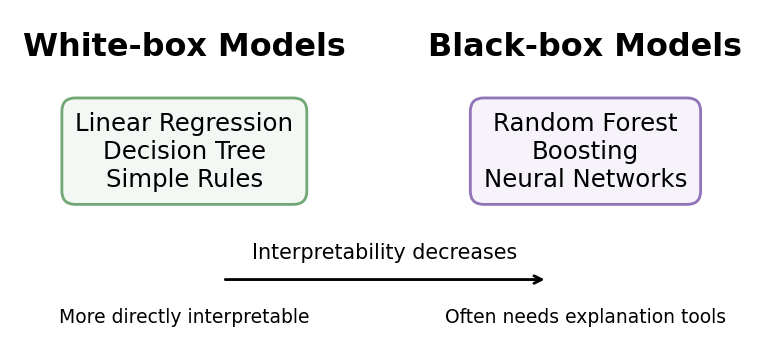</p>

</div>

<div dir="rtl">

| نوع مدل | مثال | تفسیر مستقیم |
|---|---|---|
| <bdi dir="ltr">White-box</bdi> | <bdi dir="ltr">Linear Regression</bdi> | Coefficientها قابل خواندن‌اند |
| <bdi dir="ltr">White-box</bdi> | <bdi dir="ltr">Decision Tree</bdi> کوچک | مسیر Splitها قابل دنبال‌کردن است |
| <bdi dir="ltr">Black-box</bdi> | <bdi dir="ltr">Random Forest</bdi> | تفسیر مستقیم سخت‌تر است |
| <bdi dir="ltr">Black-box</bdi> | <bdi dir="ltr">Boosting / Neural Network</bdi> | معمولاً نیازمند ابزار توضیح است |

<b>نکته:</b> Black-box بودن به معنی «بد بودن» مدل نیست؛ فقط مسیر تصمیم آن مستقیماً قابل خواندن نیست.

</div>

<div dir="rtl">

## ۴. تفسیر Coefficientهای <bdi dir="ltr">Linear Regression</bdi>

<bdi dir="ltr">Linear Regression</bdi> یک مدل White-box است، چون می‌توانیم مستقیماً Coefficient هر Feature را ببینیم.

برای مقایسه‌ی بهتر Coefficientها، ابتدا Featureها را Standardize می‌کنیم.

- Coefficient مثبت: با افزایش Feature، Prediction مدل تمایل به افزایش دارد.
- Coefficient منفی: با افزایش Feature، Prediction مدل تمایل به کاهش دارد.
- قدر مطلق بزرگ‌تر: اثر آن Feature در مدل خطی بیشتر است.

</div>

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_test_scaled)

print("R2:", round(r2_score(y_test, linear_pred), 3))
print("MAE:", round(mean_absolute_error(y_test, linear_pred), 3))

R2: 0.332
MAE: 46.174


In [ ]:
import pandas as pd

coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficient_table["Absolute Coefficient"] = coefficient_table["Coefficient"].abs()
coefficient_table = coefficient_table.sort_values("Absolute Coefficient", ascending=False)

print(coefficient_table.round(3))

  Feature  Coefficient  Absolute Coefficient
8      s5       35.838                35.838
4      s1      -31.221                31.221
2     bmi       27.511                27.511
5      s2       15.265                15.265
3      bp       14.371                14.371
1     sex      -11.586                11.586
7      s4        8.184                 8.184
9      s6        2.123                 2.123
0     age       -1.721                 1.721
6      s3        1.168                 1.168


<div dir="rtl">

<p align="center">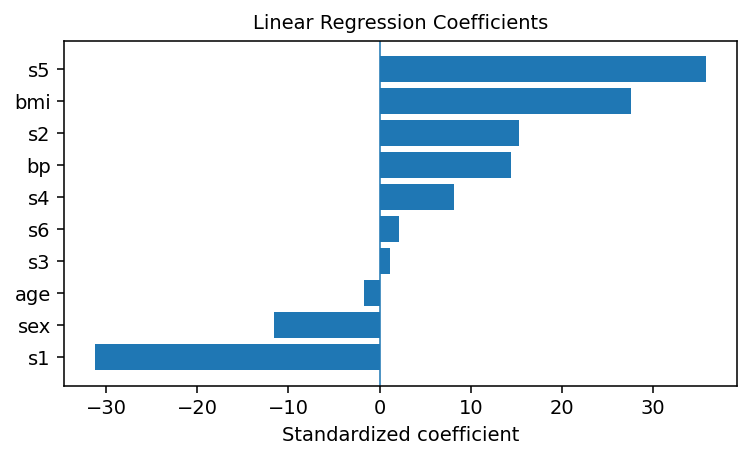</p>

### چطور Coefficient را بخوانیم؟

- Coefficient مثبت: با افزایش Feature، Prediction مدل تمایل به افزایش دارد.
- Coefficient منفی: با افزایش Feature، Prediction مدل تمایل به کاهش دارد.
- چون Featureها Standardize شده‌اند، اندازه‌ی Coefficientها راحت‌تر با هم مقایسه می‌شود.

<div class="warning-box">
<b>مهم:</b> Coefficient رابطه‌ی مدل را نشان می‌دهد، نه رابطه‌ی علت و معلولی.
</div>

</div>

<div dir="rtl">

## ۵. <bdi dir="ltr">Decision Tree</bdi> به‌عنوان یک مدل White-box

یک Decision Tree کوچک را می‌توان مستقیماً خواند.

در هر مرحله یک Feature و یک Threshold داریم و می‌توانیم مسیر Prediction را از بالای Tree تا Leaf دنبال کنیم.

برای اینکه Tree قابل‌تفسیر بماند، از <bdi dir="ltr">max_depth=2</bdi> استفاده می‌کنیم.

</div>

In [10]:
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.metrics import r2_score, mean_absolute_error

tree_model = DecisionTreeRegressor(
    max_depth=2,
    random_state=0
)

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

print("R2:", round(r2_score(y_test, tree_pred), 3))
print("MAE:", round(mean_absolute_error(y_test, tree_pred), 3))

print(export_text(tree_model, feature_names=list(X.columns)))
#print(export_text(tree_model))

R2: 0.071
MAE: 53.725
|--- s5 <= 4.88
|   |--- bmi <= 26.85
|   |   |--- value: [102.81]
|   |--- bmi >  26.85
|   |   |--- value: [172.90]
|--- s5 >  4.88
|   |--- bmi <= 27.60
|   |   |--- value: [175.59]
|   |--- bmi >  27.60
|   |   |--- value: [245.06]



<div dir="rtl">

## ۶. <bdi dir="ltr">Symbolic Regression with PySR</bdi>

در <bdi dir="ltr">Symbolic Regression</bdi> به‌جای فقط پیدا کردن Coefficientها، الگوریتم بین فرمول‌های ریاضی مختلف جست‌وجو می‌کند.

هدف این است که یک Expression نسبتاً ساده پیدا شود که Prediction خوبی داشته باشد.

برای ساده ماندن مثال، فقط دو Feature یعنی <bdi dir="ltr">bmi</bdi> و <bdi dir="ltr">s5</bdi> را به <bdi dir="ltr">PySR</bdi> می‌دهیم.

</div>

In [ ]:
!pip install -q pysr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 8.8 MB/s eta 0:00:00


In [ ]:
# Run this once if PySR is not installed:
# !pip install -q pysr

from pysr import PySRRegressor
from sklearn.metrics import r2_score

symbolic_model = PySRRegressor(
    niterations=1,
    binary_operators=["+", "-"],
#   binary_operators=["+", "-", "*", "/"],
    unary_operators=["sqrt", "abs"],
#    unary_operators=["sqrt", "log", "abs"],
    random_state=0
)

symbolic_model.fit(X_train[["bmi", "s5"]], y_train)

symbolic_pred = symbolic_model.predict(X_test[["bmi", "s5"]])

print(symbolic_model)
print("R2:", round(r2_score(y_test, symbolic_pred), 3))

[juliapkg] Found dependencies: /usr/local/lib/python3.13/dist-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.13/dist-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.13/dist-packages/pysr/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] WARNING: You have Julia 1.12.6 installed but 1.10.3 - 1.11 is required.
[juliapkg]   It is recommended that you upgrade Julia or install JuliaUp.
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.11.9 to /root/.julia/environments/pyjuliapkg/pyjuliapkg/install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[juliapkg]   have Julia installed in multiple locations. It is recommended to
[juliapkg]   install JuliaUp (https://github.com/JuliaLang/juliaup) or Julia
[juliapkg]   (https://julialang.org/downloads) yourself.
[juliapkg] Downloading Julia

Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...
/usr/local/lib/python3.13/dist-packages/pysr/sr.py:2405: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(


PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                                bmi   
	1         1.733666e-01                                          bmi + bmi   
	2         1.930308e-01                                  bmi + (bmi + bmi)   
	3         2.022111e-01                          (bmi + (bmi + bmi)) + bmi   
	4   >>>>  1.718417e-01                  bmi + ((bmi + (bmi + bmi)) + bmi)   
	5         6.244295e-02          bmi + (bmi + ((bmi + bmi) + (bmi + bmi)))   
	6         1.985386e-03  (bmi + (bmi + (((bmi + bmi) + bmi) + bmi))) - ...   
	7         5.192919e-03  ((bmi + bmi) + (bmi + (bmi + abs(bmi + bmi))))...   
	8         4.108551e-08  ((((bmi + bmi) + (bmi + (bmi + abs(bmi + bmi))...   
	9         2.819581e-03  (((bmi + (((((bmi + (bmi + -1.5727353)) + bmi)...   
	10        6.371027e-03  abs(((s5 + -1.5877234) + (bmi - 2.4407728)) + ...   
	11        1.682147e-02  abs(bmi + 

<div dir="rtl">

<p align="center">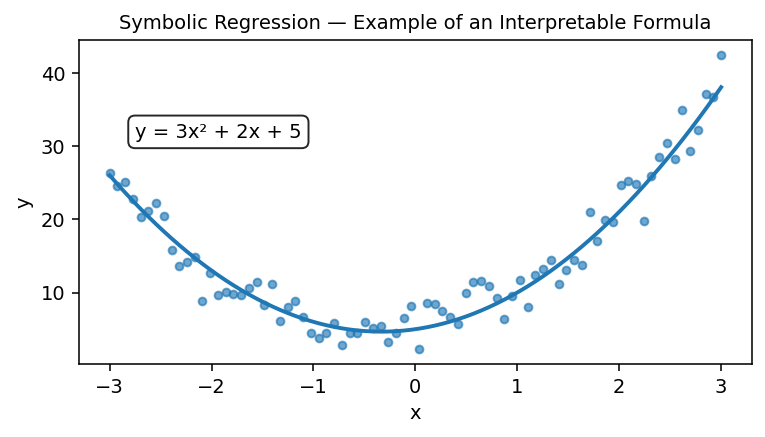</p>

<div class="note-box">
<b>نکته:</b> این شکل فقط برای نشان‌دادن نوع خروجی Symbolic Regression است. پیاده‌سازی کامل Symbolic Regression معمولاً با Libraryهای تخصصی انجام می‌شود.
</div>

</div>

<div dir="rtl">

## ۷. ساخت یک مدل <bdi dir="ltr">Random Forest</bdi>

از اینجا به بعد برای ابزارهای Explainability از یک مدل پیچیده‌تر استفاده می‌کنیم.

</div>

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

forest_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=3,
    random_state=0
)

forest_model.fit(X_train, y_train)
forest_pred = forest_model.predict(X_test)

print("R2:", round(r2_score(y_test, forest_pred), 3))
print("MAE:", round(mean_absolute_error(y_test, forest_pred), 3))

R2: 0.276
MAE: 47.569


<div dir="rtl">

## ۸. <bdi dir="ltr">Feature Importance</bdi>

<bdi dir="ltr">Random Forest</bdi> می‌تواند برای Featureها یک Importance داخلی محاسبه کند.

به‌صورت خلاصه، Featureهایی Importance بیشتری می‌گیرند که Splitهای آن‌ها کاهش بیشتری در خطای Treeها ایجاد کرده باشد.

عدد بزرگ‌تر یعنی آن Feature در تصمیم‌های مدل نقش بیشتری داشته است.

</div>

In [14]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance.round(3))

  Feature  Importance
8      s5       0.430
2     bmi       0.420
3      bp       0.059
6      s3       0.033
5      s2       0.016
9      s6       0.015
7      s4       0.012
4      s1       0.008
0     age       0.006
1     sex       0.001


<div dir="rtl">

<p align="center">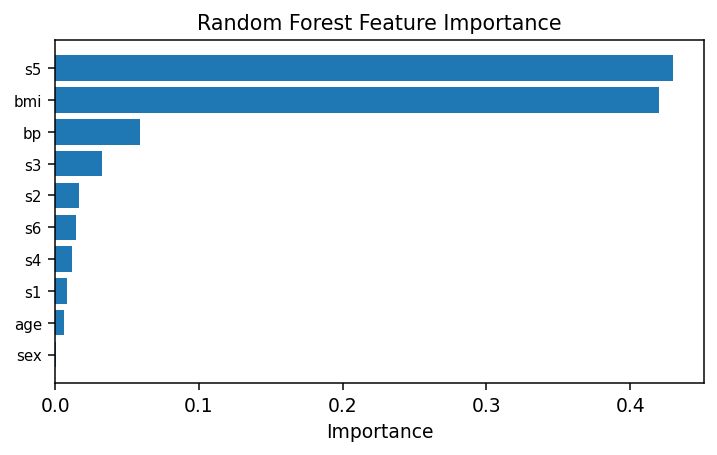</p>

</div>

<div dir="rtl">

## ۹. <bdi dir="ltr">SHAP Values</bdi>

<bdi dir="ltr">SHAP</bdi> Prediction مدل را بین Featureها تقسیم می‌کند.

### خیلی خلاصه چطور محاسبه می‌شود؟

برای هر Feature بررسی می‌شود که اضافه‌شدن آن Feature به ترکیب‌های مختلف Featureها، Prediction را چقدر تغییر می‌دهد. سپس این تغییرها با ایده‌ی <bdi dir="ltr">Shapley Values</bdi> با هم ترکیب می‌شوند.

<div class="flow-box">
<bdi dir="ltr">
Base Value + SHAP Contributions = Prediction
</bdi>
</div>

در <bdi dir="ltr">Beeswarm Plot</bdi>:

- هر نقطه = یک Observation
- محور افقی = SHAP Value
- سمت راست = افزایش Prediction
- سمت چپ = کاهش Prediction
- رنگ = مقدار Feature

</div>

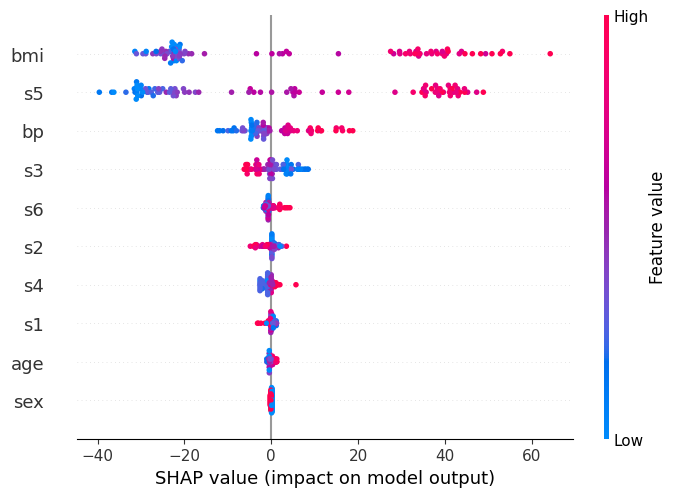

In [15]:
import shap

explainer = shap.TreeExplainer(forest_model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

In [17]:
#print(shap_values)

.values =
array([[ 1.57531968e-01, -5.30915426e-02,  6.42600298e+01,
         1.49729319e+01,  4.91493886e-01,  1.67555226e+00,
         2.58456988e+00,  3.38044286e-01,  8.05374949e-02,
         2.66997462e-01],
       [-5.73565935e-02,  4.23539273e-02,  4.63285572e+01,
         4.42202880e+00, -1.06161205e-01, -1.93611464e+00,
         1.05009686e+00,  1.79533976e-01,  3.94097174e+01,
        -1.22926267e+00],
       [-3.14330916e-01, -2.49103524e-01,  1.54694925e+01,
         8.77056556e+00,  1.13369250e+00,  2.48262257e-01,
         5.06009770e+00,  2.29647328e-01, -1.74789959e+01,
        -5.30092981e-01],
       [-4.51289143e-01,  1.98723036e-01, -2.11944755e+01,
        -3.58295661e+00,  5.70745752e-02,  8.88979944e-02,
         4.45393582e+00, -1.07722187e-02, -2.68105400e+01,
        -7.10651630e-01],
       [-7.65111707e-02,  7.45164408e-02,  5.32493489e+01,
         1.87744284e+01,  1.38669421e-01,  4.74070373e-01,
        -3.70859721e+00, -2.03660695e+00, -2.76517115e+01,
 

<div dir="rtl">

<p align="center">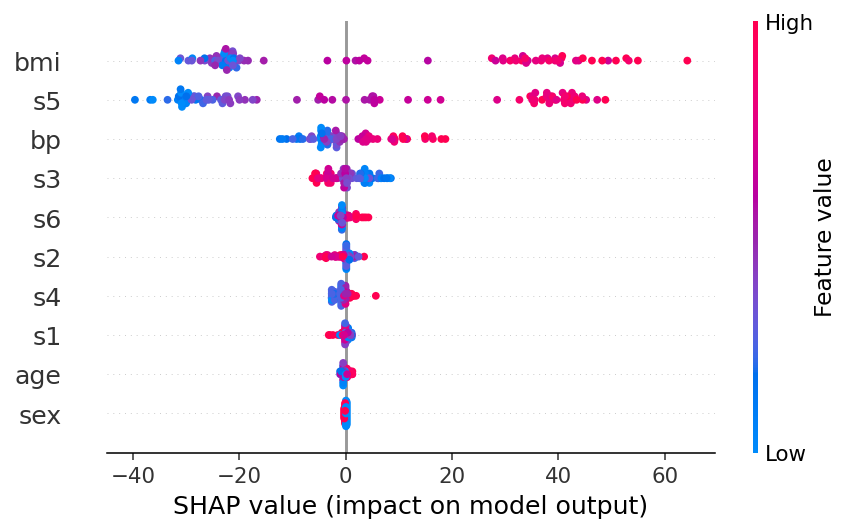</p>

</div>

In [16]:
import numpy as np
import pandas as pd

global_shap = pd.DataFrame({
    "Feature": X.columns,
    "Mean Absolute SHAP": np.abs(shap_values.values).mean(axis=0)
}).sort_values("Mean Absolute SHAP", ascending=False)

print(global_shap.round(3))

  Feature  Mean Absolute SHAP
2     bmi              28.252
8      s5              28.156
3      bp               5.429
6      s3               3.158
9      s6               1.090
5      s2               0.944
7      s4               0.890
4      s1               0.471
0     age               0.430
1     sex               0.115


<div dir="rtl">

## ۱۰. <bdi dir="ltr">Partial Dependence Plot (PDP)</bdi>

<bdi dir="ltr">PDP</bdi> اثر متوسط یک Feature روی Prediction مدل را نشان می‌دهد.

### خیلی خلاصه چطور محاسبه می‌شود؟

1. چند مقدار مختلف برای Feature انتخاب می‌کنیم.
2. برای هر مقدار، آن Feature را در همه‌ی Observationها برابر همان مقدار قرار می‌دهیم.
3. مدل برای همه‌ی Observationها Prediction می‌سازد.
4. میانگین Predictionها را می‌گیریم.

پس هر نقطه‌ی PDP یک **Average Prediction** است.

</div>

In [31]:
import numpy as np
from sklearn.inspection import partial_dependence

pdp_result = partial_dependence(
    forest_model,
    X_train,
    ["bmi"],
    grid_resolution=30
)

print(np.round(pdp_result["grid_values"][0][:10], 2))
print(np.round(pdp_result["average"][0][:10], 2))

[20.11 20.61 21.11 21.61 22.11 22.6  23.1  23.6  24.1  24.6 ]
[122.63 122.63 122.63 122.63 122.63 122.63 122.63 123.51 123.51 124.16]


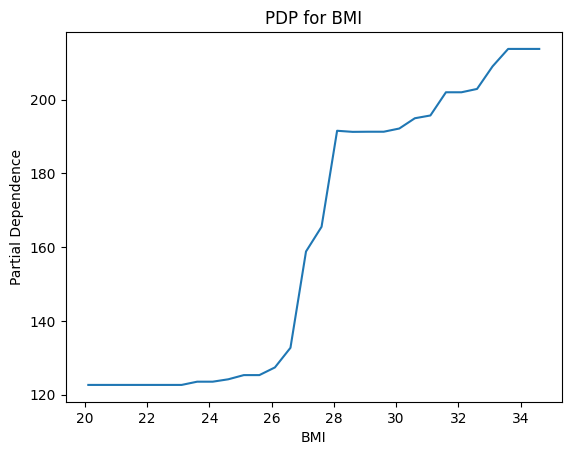

In [32]:
import matplotlib.pyplot as plt
x = pdp_result["grid_values"][0]

# y = Partial Dependence
y = pdp_result["average"][0]

# Plot
plt.plot(x, y)

plt.xlabel("BMI")
plt.ylabel("Partial Dependence")
plt.title("PDP for BMI")

plt.show()

<div dir="rtl">

<p align="center">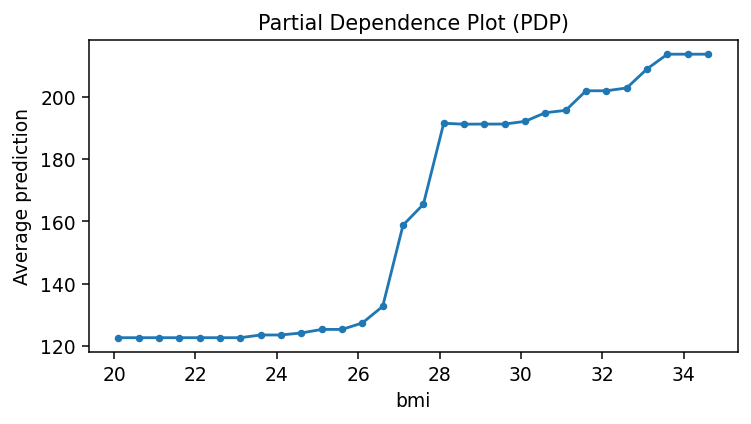</p>

</div>

<div dir="rtl">

## ۱۱. <bdi dir="ltr">Individual Conditional Expectation (ICE)</bdi>

<bdi dir="ltr">ICE</bdi> شبیه PDP است، اما میانگین نمی‌گیرد.

### خیلی خلاصه چطور محاسبه می‌شود؟

1. یک Observation را انتخاب می‌کنیم.
2. فقط مقدار Feature موردنظر را روی یک Grid تغییر می‌دهیم.
3. برای هر مقدار Prediction می‌گیریم.
4. این کار را برای Observationهای مختلف تکرار می‌کنیم.

بنابراین هر خط ICE، رفتار مدل برای **یک Observation** است.

</div>

<div dir="rtl">

<p align="center">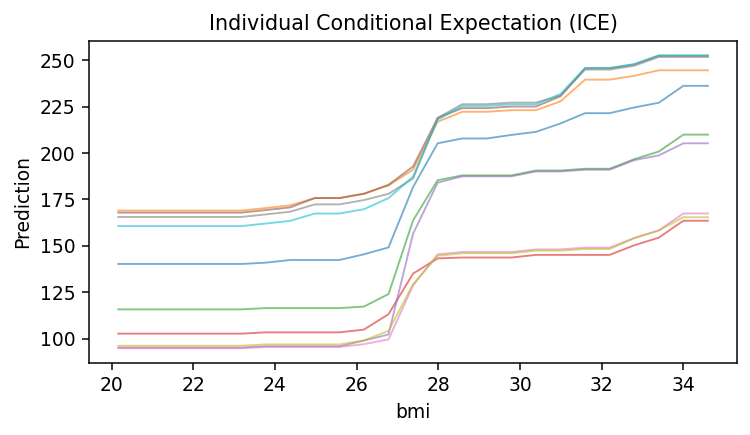</p>

</div>

[20.11 20.61 21.11 21.61 22.11 22.6  23.1  23.6  24.1  24.6 ]
(1, 353, 30)


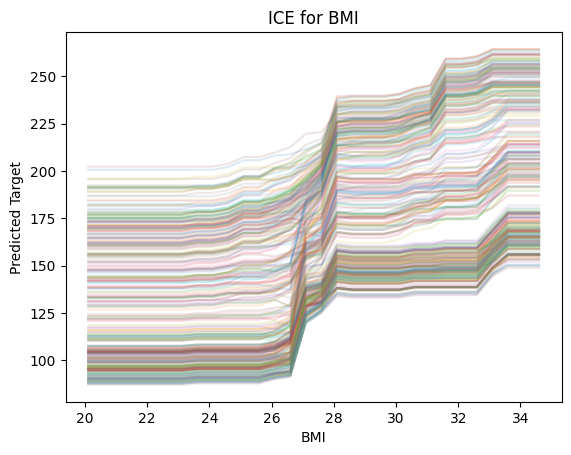

In [33]:
import numpy as np
from sklearn.inspection import partial_dependence

ice_result = partial_dependence(
    forest_model,
    X_train,
    ["bmi"],
    kind="individual",
    grid_resolution=30
)

print(np.round(
    ice_result["grid_values"][0][:10],
    2
))

print(ice_result["individual"].shape)



import matplotlib.pyplot as plt

# X-axis values
x = ice_result["grid_values"][0]

# ICE values
y = ice_result["individual"][0]

# Plot one line for each observation
for i in range(y.shape[0]):
    plt.plot(
        x,
        y[i],
        alpha=0.15
    )

plt.xlabel("BMI")
plt.ylabel("Predicted Target")
plt.title("ICE for BMI")

plt.show()

<div dir="rtl">

## ۱۲. <bdi dir="ltr">Accumulated Local Effects (ALE)</bdi>

<bdi dir="ltr">ALE</bdi> اثر Feature را به‌صورت Local بررسی می‌کند و سپس این اثرهای Local را روی هم جمع می‌کند.

### خیلی خلاصه چطور محاسبه می‌شود؟

1. دامنه‌ی Feature را به چند Interval تقسیم می‌کنیم.
2. داخل هر Interval، Prediction را در ابتدا و انتهای Interval مقایسه می‌کنیم.
3. تفاوت Predictionها را برای Observationهای همان Interval میانگین می‌گیریم.
4. این اثرهای Local را به‌صورت تجمعی جمع و در پایان Center می‌کنیم.

ALE معمولاً در حضور Featureهای Correlated از PDP کمتر به ترکیب‌های غیرواقعی وابسته می‌شود.

</div>

<div dir="rtl">

<p align="center">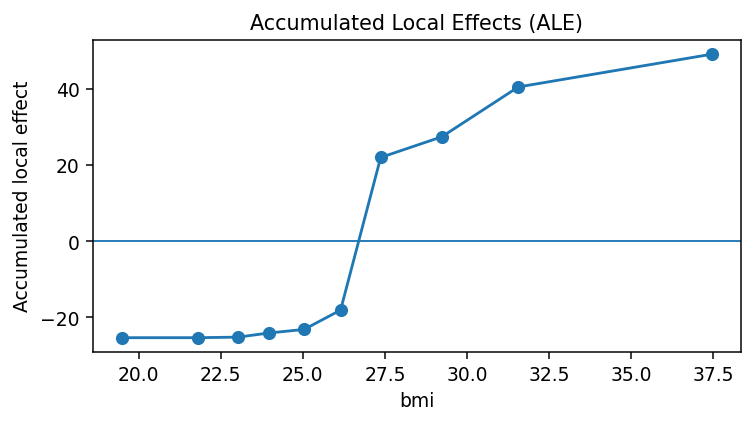</p>

</div>

In [36]:
!pip install PyALE

INFO:PyALE._ALE_generic:Continuous feature detected.


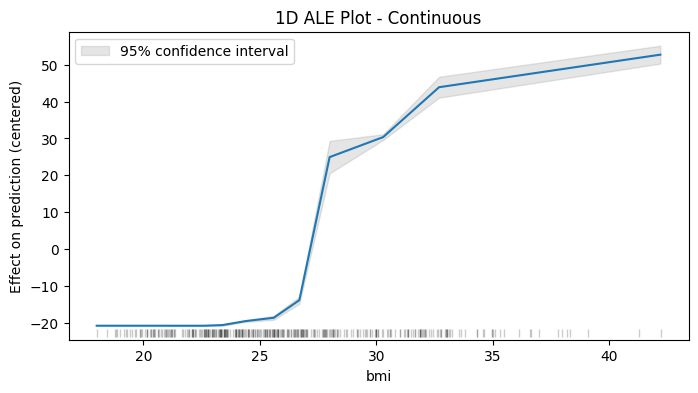

In [38]:
from PyALE import ale

ale_result = ale(
    X=X_train,
    model=forest_model,
    feature=["bmi"],
    grid_size=10,
    include_CI=False
)

<div dir="rtl">

## ۱۳. <bdi dir="ltr">Permutation Feature Importance</bdi>

ایده خیلی ساده است:

1. Performance اصلی مدل را اندازه می‌گیریم.
2. مقادیر یک Feature را Shuffle می‌کنیم.
3. دوباره Performance را اندازه می‌گیریم.
4. افت Performance = Importance آن Feature.

اگر Shuffle کردن یک Feature مدل را خیلی خراب کند، آن Feature برای مدل مهم بوده است.

</div>

In [39]:
import pandas as pd
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    forest_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=0,
    scoring="r2"
)

permutation_table = pd.DataFrame({
    "Feature": X.columns,
    "Permutation Importance": permutation_result.importances_mean
}).sort_values("Permutation Importance", ascending=False)

print(permutation_table.round(3))

  Feature  Permutation Importance
8      s5                   0.201
2     bmi                   0.152
3      bp                   0.035
6      s3                   0.006
5      s2                   0.006
9      s6                   0.005
0     age                   0.001
1     sex                   0.000
7      s4                  -0.001
4      s1                  -0.003


<div dir="rtl">

<p align="center">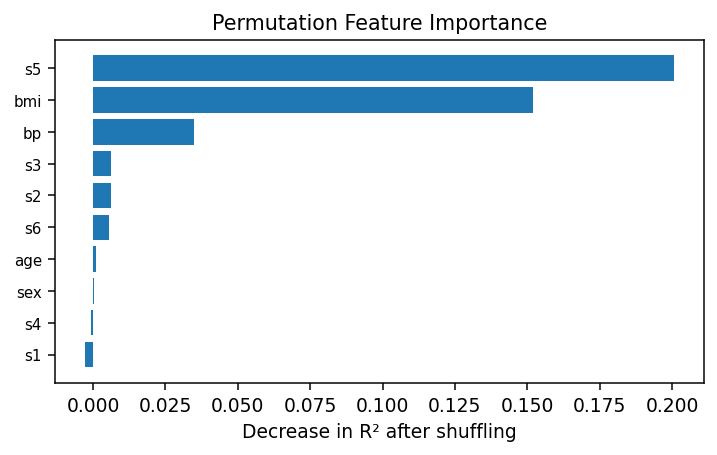</p>

</div>

<div dir="rtl">

## ۱۴. مقایسه‌ی <bdi dir="ltr">PDP</bdi>، <bdi dir="ltr">ICE</bdi> و <bdi dir="ltr">ALE</bdi>

| روش | نوع توضیح | سؤال اصلی |
|---|---|---|
| <bdi dir="ltr">PDP</bdi> | Global | اثر متوسط Feature چیست؟ |
| <bdi dir="ltr">ICE</bdi> | Local curves | اثر Feature برای هر Observation چگونه است؟ |
| <bdi dir="ltr">ALE</bdi> | Global | اثر Local تجمعی Feature چیست؟ |

</div>

<div dir="rtl">

## ۱۵. ابزارهای توضیح Global

| سؤال | ابزار مناسب |
|---|---|
| مدل در کل بیشتر به چه Featureهایی وابسته است؟ | Feature Importance / Permutation / Global SHAP |
| اثر متوسط یک Feature چیست؟ | PDP / ALE |
| آیا اثر Feature برای Observationهای مختلف متفاوت است؟ | ICE |
| آیا خود مدل مستقیماً قابل خواندن است؟ | Coefficients / Small Tree / Symbolic Regression |

</div>

<div dir="rtl" class="warning-box">

## ۱۶. محدودیت‌های Explainability

یک Explanation لزوماً به معنی حقیقت علمی یا رابطه‌ی علت و معلولی نیست.

چند نکته‌ی مهم:

- Feature Importance می‌تواند تحت تأثیر Correlation بین Featureها باشد.
- PDP ممکن است ترکیب‌های غیرواقعی Featureها را بررسی کند.
- SHAP رفتار **مدل** را توضیح می‌دهد، نه الزاماً رفتار دنیای واقعی را.
- نتیجه‌ی Explainability باید همراه با شناخت Domain تفسیر شود.

</div>

<div dir="rtl">

## ۱۷. Workflow ساده برای Explainable ML

<div class="flow-box">
<bdi dir="ltr">
1. Train and evaluate the model<br>
↓<br>
2. Start with a global interpretation method<br>
↓<br>
3. Compare Feature Importance and SHAP<br>
↓<br>
4. Study feature effects with PDP / ICE / ALE<br>
↓<br>
5. Check correlated features and unrealistic assumptions<br>
↓<br>
6. Interpret results with domain knowledge
</bdi>
</div>

</div>

<div dir="rtl">

## ۱۸. Quiz کوتاه

### سؤال ۱
کدام مدل معمولاً White-box محسوب می‌شود؟

<span dir="ltr">A.</span> Linear Regression  
<span dir="ltr">B.</span> Random Forest با ۱۰۰۰ درخت  
<span dir="ltr">C.</span> Neural Network عمیق

### سؤال ۲
علامت مثبت یک Coefficient در Linear Regression چه چیزی را نشان می‌دهد؟

<span dir="ltr">A.</span> با افزایش Feature، Prediction مدل تمایل به افزایش دارد  
<span dir="ltr">B.</span> Feature حتماً علت Target است  
<span dir="ltr">C.</span> مدل Overfit شده است

### سؤال ۳
Permutation Importance چه کاری انجام می‌دهد؟

<span dir="ltr">A.</span> Feature را Shuffle می‌کند و افت Performance را بررسی می‌کند  
<span dir="ltr">B.</span> Feature را حذف می‌کند و مدل را از اول می‌سازد  
<span dir="ltr">C.</span> فقط Correlation را محاسبه می‌کند

### سؤال ۴
فرق اصلی PDP و ICE چیست؟

<span dir="ltr">A.</span> PDP رفتار متوسط و ICE رفتار Observationهای جداگانه را نشان می‌دهد  
<span dir="ltr">B.</span> هیچ فرقی ندارند  
<span dir="ltr">C.</span> ICE فقط برای Classification است

### سؤال ۵
Global SHAP چه چیزی را خلاصه می‌کند؟

<span dir="ltr">A.</span> اهمیت و Contribution کلی Featureها در Predictionهای مدل  
<span dir="ltr">B.</span> تعداد Foldها  
<span dir="ltr">C.</span> فقط Correlation بین Featureها

### سؤال ۶
آیا SHAP رابطه‌ی علت و معلولی را اثبات می‌کند؟

<span dir="ltr">A.</span> بله  
<span dir="ltr">B.</span> خیر

</div>

<div dir="rtl">

<details>
<summary><b>پاسخ Quiz — برای مشاهده کلیک کنید</b></summary>

<p><b>۱. A —</b> Linear Regression</p>
<p><b>۲. A —</b> Prediction مدل تمایل به افزایش دارد.</p>
<p><b>۳. A —</b> Feature را Shuffle می‌کند و افت Performance را بررسی می‌کند.</p>
<p><b>۴. A —</b> PDP میانگین است و ICE Observationهای جداگانه را نشان می‌دهد.</p>
<p><b>۵. A —</b> Contribution کلی Featureها را در مدل خلاصه می‌کند.</p>
<p><b>۶. B —</b> خیر؛ SHAP رفتار مدل را توضیح می‌دهد.</p>

</details>

</div>

<div dir="rtl">

## ۱۹. تمرین ۱ — Coefficient Interpretation

جدول Coefficientهای Linear Regression را بررسی کنید.

### سؤال‌ها

1. کدام Feature بزرگ‌ترین Coefficient مثبت را دارد؟
2. کدام Feature بزرگ‌ترین Coefficient منفی را دارد؟
3. علامت مثبت و منفی را با زبان ساده تفسیر کنید.

</div>

In [ ]:
# Sort coefficients from largest to smallest.
exercise_coefficients = coefficient_table.sort_values(
    "Coefficient",
    ascending=False
)

print(exercise_coefficients.round(3))

  Feature  Coefficient  Absolute Coefficient
8      s5       35.838                35.838
2     bmi       27.511                27.511
5      s2       15.265                15.265
3      bp       14.371                14.371
7      s4        8.184                 8.184
9      s6        2.123                 2.123
6      s3        1.168                 1.168
0     age       -1.721                 1.721
1     sex      -11.586                11.586
4      s1      -31.221                31.221


<div dir="rtl">

## ۲۰. تمرین ۲ — Feature Importance vs Permutation Importance

دو جدول زیر را با هم مقایسه کنید:

- <bdi dir="ltr">feature_importance</bdi>
- <bdi dir="ltr">permutation_table</bdi>

### سؤال

آیا ترتیب Featureهای مهم در دو روش دقیقاً یکسان است؟ اگر نه، چرا ممکن است فرق داشته باشند؟

</div>

In [ ]:
comparison = feature_importance.merge(
    permutation_table,
    on="Feature"
)

print(comparison.round(3))

  Feature  Importance  Permutation Importance
0      s5       0.430                   0.201
1     bmi       0.420                   0.152
2      bp       0.059                   0.035
3      s3       0.033                   0.006
4      s2       0.016                   0.006
5      s6       0.015                   0.005
6      s4       0.012                  -0.001
7      s1       0.008                  -0.003
8     age       0.006                   0.001
9     sex       0.001                   0.000


<div dir="rtl">

## ۲۱. تمرین ۳ — Global SHAP

جدول <bdi dir="ltr">global_shap</bdi> را بررسی کنید.

### سؤال‌ها

1. سه Feature مهم اول از دید SHAP کدام‌اند؟
2. آیا ترتیب آن‌ها با Feature Importance دقیقاً یکسان است؟
3. اگر تفاوت وجود دارد، چرا ممکن است دو روش نتیجه‌ی متفاوتی بدهند؟

</div>

In [ ]:
print(global_shap.head(5).round(3))

  Feature  Mean Absolute SHAP
2     bmi              28.252
8      s5              28.156
3      bp               5.429
6      s3               3.158
9      s6               1.090


<div dir="rtl">

# جمع‌بندی جلسه ۷

در این جلسه دیدیم که Explainability فقط یک ابزار واحد نیست.

روش‌های اصلی:

- <bdi dir="ltr">White-box vs Black-box Models</bdi>
- Regression Coefficients
- <bdi dir="ltr">Decision Tree</bdi> کوچک به‌عنوان White-box
- <bdi dir="ltr">Symbolic Regression with PySR</bdi>
- <bdi dir="ltr">Feature Importance</bdi>
- <bdi dir="ltr">SHAP Beeswarm</bdi>
- <bdi dir="ltr">PDP</bdi>
- <bdi dir="ltr">ICE</bdi>
- <bdi dir="ltr">ALE</bdi>
- <bdi dir="ltr">Permutation Importance</bdi>

> پیام اصلی جلسه:  
> **Performance به ما می‌گوید مدل چقدر خوب Predict می‌کند؛ Explainability کمک می‌کند بفهمیم مدل چگونه به Prediction رسیده است.**

</div>